In [26]:
# Standard Data Package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datetime Package
from datetime import datetime

# Serialization Package
import joblib

In [27]:
data = joblib.load("../data/processed/cleaned_data.pkl")

In [28]:
# Data Preview
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [29]:
# Extracting Month from InvoiceDate
data['Month'] = data['InvoiceDate'].apply(lambda x: datetime(x.year, x.month, 1))

# Validation
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01


In [30]:
# Create and Extract each customer Cohortmonth
data['CohortMonth'] = data.groupby(by='Customer ID')['Month'].transform('min')

# Validation
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,Month,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12-01


In [31]:
# Creating Cohort Index for each transaction
def calculate_cohortindex(data_cohort):
    "Calculate month difference from first transaction to the current transaction"

    cohort_month = data_cohort['CohortMonth'].dt.month
    cohort_year = data_cohort['CohortMonth'].dt.year

    tn_month = data_cohort['Month'].dt.month
    tn_year = data_cohort['Month'].dt.year

    monthdiff = tn_month-cohort_month
    yeardiff = tn_year - cohort_year

    index = yeardiff*12 + monthdiff + 1

    return index

In [32]:
data['CohortIndex']= calculate_cohortindex(data)
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,Month,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12-01,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12-01,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12-01,1


In [33]:
cohort_data = data.groupby(['CohortMonth','CohortIndex'])['Customer ID'].agg("nunique").reset_index(name = "NumCustomer")
cohort_data.head()

,CohortMonth,CohortIndex,NumCustomer
0,2009-12-01,1,955
1,2009-12-01,2,337
2,2009-12-01,3,319
3,2009-12-01,4,406
4,2009-12-01,5,363


In [34]:
cohort_pivot = cohort_data.pivot_table(
    index="CohortMonth",
    columns="CohortIndex",
    values="NumCustomer"
)

cohort_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12-01,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,237.0
2010-01-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,38.0,NaN
2010-02-01,376.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,27.0,NaN,NaN
2010-03-01,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,35.0,NaN,NaN,NaN
2010-04-01,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,20.0,NaN,NaN,NaN,NaN
2010-05-01,254.0,40.0,43.0,44.0,45.0,65.0,54.0,20.0,NaN,NaN,NaN,NaN,NaN
2010-06-01,270.0,47.0,51.0,55.0,62.0,77.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,186.0,29.0,34.0,55.0,54.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,162.0,33.0,48.0,52.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
retention = cohort_pivot.divide(cohort_pivot[1], axis=0)
retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12-01,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,0.421990,0.495288,0.248168
2010-01-01,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,0.302872,0.099217,NaN
2010-02-01,1.0,0.236702,0.223404,0.289894,0.244681,0.199468,0.191489,0.284574,0.252660,0.273936,0.071809,NaN,NaN
2010-03-01,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.079007,NaN,NaN,NaN
2010-04-01,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.068027,NaN,NaN,NaN,NaN
2010-05-01,1.0,0.157480,0.169291,0.173228,0.177165,0.255906,0.212598,0.078740,NaN,NaN,NaN,NaN,NaN
2010-06-01,1.0,0.174074,0.188889,0.203704,0.229630,0.285185,0.066667,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-01,1.0,0.155914,0.182796,0.295699,0.290323,0.102151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08-01,1.0,0.203704,0.296296,0.320988,0.117284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
retention.index = retention.index.astype('period[M]')

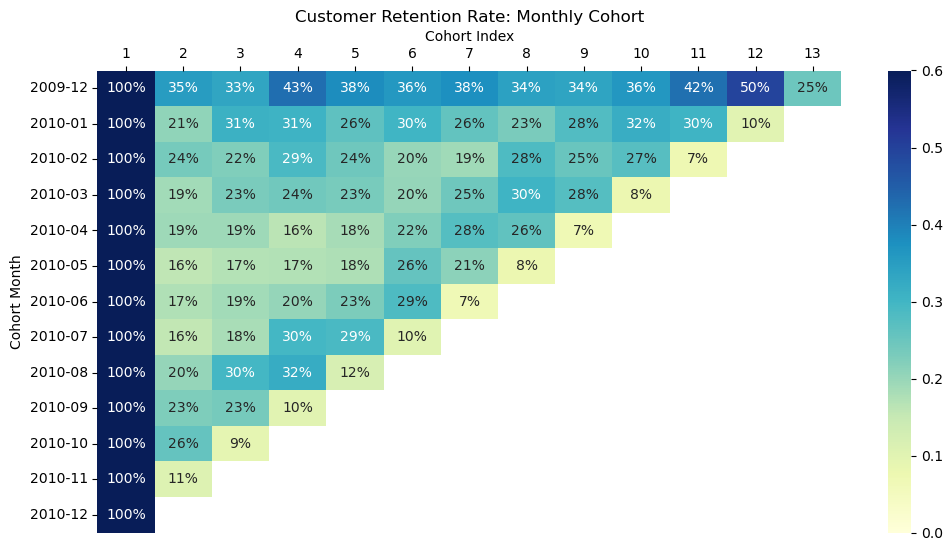

In [37]:
plt.figure(figsize=(12,6))
plt.title("Customer Retention Rate: Monthly Cohort")
sns.heatmap(retention, annot=True, fmt=".0%", cmap="YlGnBu", vmin = 0.0 , vmax = 0.6)
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')

#Pindahkan x axis ke atas
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.show()


- Since the data only contains data from 1st December 2009 to 9th December 2010, the low retention rate in December 2010 was due to incomplete data.

In [38]:
mask = pd.DataFrame(True, index=retention.index, columns=retention.columns)

n = len(retention)
# tandai anti-diagonal sebagai False
for i in range(n):
    mask.iloc[i, n - 1 - i] = False

mask

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,True,True,True,True,True,True,True,True,True,True,True,True,False
2010-01,True,True,True,True,True,True,True,True,True,True,True,False,True
2010-02,True,True,True,True,True,True,True,True,True,True,False,True,True
2010-03,True,True,True,True,True,True,True,True,True,False,True,True,True
2010-04,True,True,True,True,True,True,True,True,False,True,True,True,True
2010-05,True,True,True,True,True,True,True,False,True,True,True,True,True
2010-06,True,True,True,True,True,True,False,True,True,True,True,True,True
2010-07,True,True,True,True,True,False,True,True,True,True,True,True,True
2010-08,True,True,True,True,False,True,True,True,True,True,True,True,True


In [39]:
# Calculate the average retention rate using all the data
print("Calculation with all the data")
print("-----------------------------")
avg_ret_rate = retention.iloc[:,1:].mean().mean()

print(f'Average monthly retention rate: {avg_ret_rate*100:.2f} %')

# Calculate Churn Rate
churn_rate = 1 - avg_ret_rate
print(f'Average monthly churn rate: {churn_rate*100:.2f} %')

print('')
print('Calculation without December 2010')
print("---------------------------------")
# Calculating average retention rate without December 2010
# Calculate the average retention rate
avg_ret_rate_wo_dec = retention[mask].iloc[:,1:].mean().mean()
print(f'Average monthly retention rate: {avg_ret_rate_wo_dec*100:.2f} %')

# Calculate Churn Rate
churn_rate_wo_dec = 1 - avg_ret_rate_wo_dec
print(f'Average monthly churn rate: {churn_rate_wo_dec*100:.2f} %')



Calculation with all the data
-----------------------------
Average monthly retention rate: 24.59 %
Average monthly churn rate: 75.41 %

Calculation without December 2010
---------------------------------
Average monthly retention rate: 29.43 %
Average monthly churn rate: 70.57 %


In [40]:
# Calculating each Cohort Index retention rate
avg_by_index = pd.DataFrame((retention[mask].iloc[:, 1:11].mean() * 100).round(2).astype(str) + '%')
avg_by_index.T


CohortIndex,2,3,4,5,6,7,8,9,10,11
0,21.4%,23.64%,26.88%,25.02%,26.11%,26.02%,28.42%,28.59%,31.83%,36.24%


**Insights**:

- On Average, only 21.4% of customer made a transaction after their first purchase month indicating extremely low early retention.
- Cohort 2009-01 outperforms others in retention. This may indicate that the acquisition campaign in that period likely attracted higher-quality customers leading to better retention in the following months.
- Customers who remain active after CohortIndex = 3 show stable retention out to 6+ months. This indicates the presence of a small but loyal customer base.
- The expected churn rate for each period is 64.69%. Company needs to implement strategies to decrease user churn during this period (December 2010).

---
- Let's see how many of each months transaction comes from the reapeating customer during the month.

In [41]:
groupby_invoice = data.groupby(['Invoice','InvoiceDate', 'Customer ID'])['Total_Price'].sum()
groupby_invoice = groupby_invoice.sort_values(ascending=False).reset_index()
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price
0,493819,2010-01-07 12:34:00,14156,44051.60
1,524181,2010-09-27 16:59:00,17450,33167.80
2,526934,2010-10-14 09:46:00,18102,26007.08
3,515944,2010-07-15 15:29:00,18102,22863.36
4,517731,2010-08-01 13:31:00,18102,21984.00


In [42]:
#Calculate each customer number of transaction in each month
monthly_trans_cnt = groupby_invoice.groupby([pd.Grouper(key='InvoiceDate',freq='M'), 'Customer ID'])['Invoice'].nunique().reset_index()

#Repeating Customer
repeat_cust = monthly_trans_cnt[monthly_trans_cnt['Invoice']>1]
repeat_cust.head()

C:\Users\daffa\AppData\Local\Temp\ipykernel_17764\1472670497.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trans_cnt = groupby_invoice.groupby([pd.Grouper(key='InvoiceDate',freq='M'), 'Customer ID'])['Invoice'].nunique().reset_index()


,InvoiceDate,Customer ID,Invoice
0,2009-12-31,12346,5
2,2009-12-31,12359,2
4,2009-12-31,12417,2
12,2009-12-31,12471,7
19,2009-12-31,12539,2


- Let's look at the number of repeat customer in each month

In [43]:
repeat_cust_cnt = repeat_cust.groupby(pd.Grouper(key='InvoiceDate',freq='M'))['Customer ID'].nunique().reset_index()
repeat_cust_cnt

C:\Users\daffa\AppData\Local\Temp\ipykernel_17764\3523854746.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  repeat_cust_cnt = repeat_cust.groupby(pd.Grouper(key='InvoiceDate',freq='M'))['Customer ID'].nunique().reset_index()


,InvoiceDate,Customer ID
0,2009-12-31,286
1,2010-01-31,148
2,2010-02-28,175
3,2010-03-31,237
4,2010-04-30,202
5,2010-05-31,228
6,2010-06-30,257
7,2010-07-31,255
8,2010-08-31,219
9,2010-09-30,270


- Let's look at the number of unique customers making transactions each month.

In [44]:
unique_cust = monthly_trans_cnt.groupby(pd.Grouper(key='InvoiceDate',freq='M'))['Customer ID'].nunique().reset_index()
unique_cust

C:\Users\daffa\AppData\Local\Temp\ipykernel_17764\2623420831.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  unique_cust = monthly_trans_cnt.groupby(pd.Grouper(key='InvoiceDate',freq='M'))['Customer ID'].nunique().reset_index()


,InvoiceDate,Customer ID
0,2009-12-31,955
1,2010-01-31,720
2,2010-02-28,774
3,2010-03-31,1057
4,2010-04-30,942
5,2010-05-31,966
6,2010-06-30,1041
7,2010-07-31,928
8,2010-08-31,911
9,2010-09-30,1145
